# Exploring the MESI & Munster eddy datasets
### Authors: Cara Wilson & Madison Richardson

> History | Updated March 2026


This code explores the eddy field around a cruise track using a number of different datasets: Sea level anomalies from satellite altimetery and the MESI and MUNSTER dataset. Underway ship data from NOAA ship the Nancy Foster that was in the Gulf in June 2025. First 4 different maps are made of the region the ship went though, plotting SSH (sea surface height anomaly), EKE (eddy kinetic energy), MESI (multiparameter eddy strength index) and the positions of cyclonic and anticyclonic eddies). Then maps are made showing the values of EKE, MESI and the eddy ID numbers synoptic with the cruise track.

## Load Packages

In [1]:
import sys
import subprocess
import importlib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
from erddapy import ERDDAP
from adjustText import adjust_text
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Get the ship underway data for Nancy Foster in the Gulf in June 2025

In [ ]:
# Define ERDDAP dataset ID
dataset = "fsuNoaaShipWTER"

# Initialize ERDDAP connection
e = ERDDAP(
    server="https://coastwatch.pfeg.noaa.gov/erddap",  # ERDDAP server URL
    protocol="tabledap",                              # tabular data access
    response="csv",                                   # return format
)

# Specify dataset and variables to retrieve
e.dataset_id = dataset
e.variables = ["longitude", "latitude", "time", "salinity", "seaTemperature"]

# Define time constraints for the query
e.constraints = {
    "time>=": "2025-06-10",
    "time<=": "2025-06-19",
}

# Download data as a pandas DataFrame
ship = e.to_pandas(parse_dates=True)

# Clean column names (remove units like " (degrees_east)")
ship.columns = ship.columns.str.replace(r" \(.*\)", "", regex=True)

# Convert longitude from 0–360 to -180–180 for plotting
ship["longitude"] = ship["longitude"] - 360

# Rename variables to match desired naming convention
ship = ship.rename(columns={
    "seaTemperature": "Ship_SST",
    "salinity": "Salinity"
})

## Subset track every 2 hours

In [3]:
# Initially tried averaging into a daily product, but that produced points
# that were not actually along the survey track and did not have enough
# track coverage, so instead subset every 2 hours.

ship_2 = ship.iloc[::120].reset_index(drop=True)

ship_2.head()

,longitude,latitude,time,Salinity,Ship_SST
0,-89.0917,30.36042,2025-06-10T00:00:00Z,NaN,NaN
1,-89.0917,30.36042,2025-06-10T02:00:00Z,NaN,NaN
2,-89.0917,30.36042,2025-06-10T04:00:00Z,NaN,NaN
3,-89.0917,30.36042,2025-06-10T06:00:00Z,NaN,NaN
4,-89.0917,30.36042,2025-06-10T08:00:00Z,NaN,NaN


## Get boundaries of trackline

In [4]:
# Ensure time is datetime
ship["time"] = pd.to_datetime(ship["time"])

# Ranges and midpoint
trange = ship["time"].agg(["min", "max"]).tolist()
midt = ship["time"].median().date().isoformat()
xrange = ship["longitude"].agg(["min", "max"]).tolist()
yrange = ship["latitude"].agg(["min", "max"]).tolist()

print("trange:", trange)
print("midt:", midt)
print("xrange:", xrange)
print("yrange:", yrange)

trange: [Timestamp('2025-06-10 00:00:00+0000', tz='UTC'), Timestamp('2025-06-19 00:00:00+0000', tz='UTC')]
midt: 2025-06-14
xrange: [-92.61349999999999, -81.11783000000003]
yrange: [24.34284, 30.36045]


## Get fields of eke, SLA and eddy labels

In [ ]:
# The MESI data set contains SSH, EKE and the MESI data, while the MUNSTER dataset provides the
# unique identification of specific eddies.
# Here the data is being extracted for only one day, for the entire region traversed by the ship.

# ERDDAP griddap dataset URLs
mesi_url = "https://coastwatch.noaa.gov/erddap/griddap/noaacweddymesiplusdaily"
munster_url = "https://coastwatch.noaa.gov/erddap/griddap/noaacweddymunsterdaily"

# Open datasets with xarray
mesi_ds = xr.open_dataset(mesi_url)
munster_ds = xr.open_dataset(munster_url)

# Define padding to expand spatial bounds around ship track
data_xpad = 0.5
data_ypad = 0.5

# Compute spatial bounds with padding
data_xmin = xrange[0] - data_xpad
data_xmax = xrange[1] + data_xpad
data_ymin = yrange[0] - data_ypad
data_ymax = yrange[1] + data_ypad

# Subset MESI dataset (select nearest time, then spatial region)
mesi_2d = (
    mesi_ds[["mesi", "ssh", "eke"]]
    .sel(time=midt, method="nearest")
    .sel(
        latitude=slice(data_ymin, data_ymax),
        longitude=slice(data_xmin, data_xmax)
    )
)

# Subset eddy label dataset (same region and time)
eddy_2d = (
    munster_ds[["Label_cyclo", "Label_anti"]]
    .sel(time=midt, method="nearest")
    .sel(
        latitude=slice(data_ymin, data_ymax),
        longitude=slice(data_xmin, data_xmax)
    )
)

# Multiply cyclonic eddy IDs by -1 so they are distinguishable from anticyclonic
eddy_2d["Label_cyclo"] = -eddy_2d["Label_cyclo"]

# Convert MESI dataset to long (tidy) format for plotting
mesi_df = mesi_2d.to_dataframe().reset_index().melt(
    id_vars=["longitude", "latitude", "time"],
    var_name="variable",
    value_name="value"
)

# Convert eddy dataset to long (tidy) format for plotting
eddy_df = eddy_2d.to_dataframe().reset_index().melt(
    id_vars=["longitude", "latitude", "time"],
    var_name="variable",
    value_name="value"
)

# Preview data
mesi_df.head(), eddy_df.head()

(   longitude  latitude       time variable     value
 0    -92.875    23.875 2025-06-13     mesi -0.000241
 1    -92.625    23.875 2025-06-13     mesi  0.000977
 2    -92.375    23.875 2025-06-13     mesi  0.005590
 3    -92.125    23.875 2025-06-13     mesi  0.007951
 4    -91.875    23.875 2025-06-13     mesi  0.009551,
    longitude  latitude       time     variable   value
 0    -92.875    23.875 2025-06-14  Label_cyclo -3053.0
 1    -92.625    23.875 2025-06-14  Label_cyclo -3053.0
 2    -92.375    23.875 2025-06-14  Label_cyclo -3053.0
 3    -92.125    23.875 2025-06-14  Label_cyclo -3053.0
 4    -91.875    23.875 2025-06-14  Label_cyclo -3053.0)

## Make map of SSH

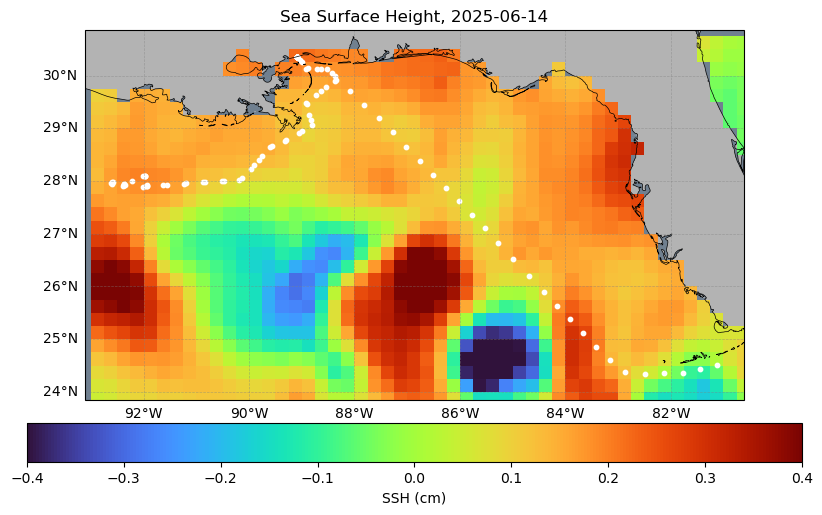

In [ ]:
# Plot sea surface height (SSH)

# Subset SSH data from long-format dataframe
map_data_subset = mesi_df[mesi_df["variable"] == "ssh"]

# Convert to grid format (latitude × longitude)
grid = map_data_subset.pivot(index="latitude", columns="longitude", values="value")

# Create map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot SSH raster field
mesh = ax.pcolormesh(
    grid.columns.values,
    grid.index.values,
    grid.values,
    cmap="turbo",               # color palette
    vmin=-0.4,
    vmax=0.4,
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Add land and coastline
ax.add_feature(cfeature.LAND, facecolor="0.7")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Overlay ship track
ax.scatter(
    ship_2["longitude"],
    ship_2["latitude"],
    color="white",
    s=10,
    transform=ccrs.PlateCarree()
)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Title
ax.set_title(f"Sea Surface Height, {midt}")

# Background color
ax.set_facecolor("slategray")

# Colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("SSH (cm)")

# Define padding for map extent
plot_xpad = 0.5
plot_ypad = 0.5

# Set map extent around ship track
ax.set_extent(
    [
        ship_2["longitude"].min() - plot_xpad,
        ship_2["longitude"].max() + plot_xpad,
        ship_2["latitude"].min() - plot_ypad,
        ship_2["latitude"].max() + plot_ypad,
    ],
    crs=ccrs.PlateCarree()
)

# Save and display
plt.savefig("SSHmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Make map of EKE

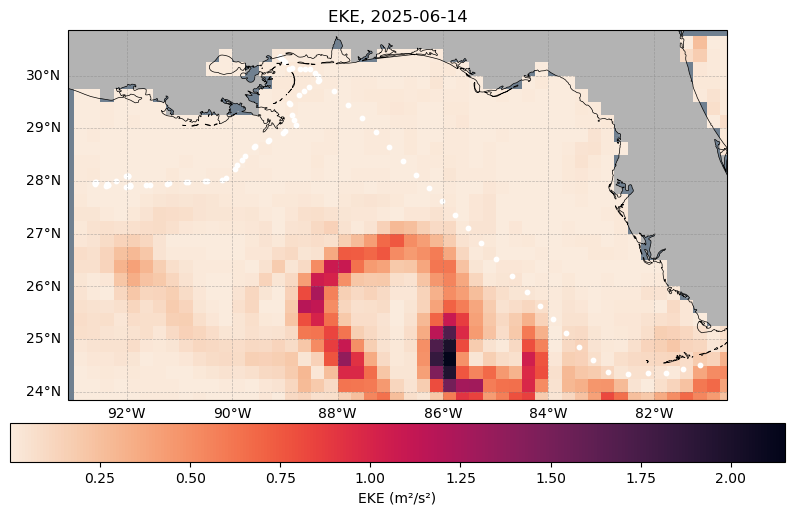

In [ ]:
# Plot eddy kinetic energy (EKE)

# Subset EKE data
map_data_subset = mesi_df[mesi_df["variable"] == "eke"]

# Convert to grid for plotting
grid = map_data_subset.pivot(index="latitude", columns="longitude", values="value")

# Create map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot raster (EKE field)
mesh = ax.pcolormesh(
    grid.columns.values,
    grid.index.values,
    grid.values,
    cmap="rocket_r",              # reversed color palette
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Add land and coastline
ax.add_feature(cfeature.LAND, facecolor="0.7")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Overlay ship track
ax.scatter(
    ship_2["longitude"],
    ship_2["latitude"],
    color="white",
    s=10,
    transform=ccrs.PlateCarree()
)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Title
ax.set_title(f"EKE, {midt}")

# Background color
ax.set_facecolor("slategray")

# Colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("EKE (m²/s²)")

# Set map extent around ship track
ax.set_extent(
    [
        ship_2["longitude"].min() - plot_xpad,
        ship_2["longitude"].max() + plot_xpad,
        ship_2["latitude"].min() - plot_ypad,
        ship_2["latitude"].max() + plot_ypad,
    ],
    crs=ccrs.PlateCarree()
)

# Save and display
plt.savefig("EKEmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Make map of MESI

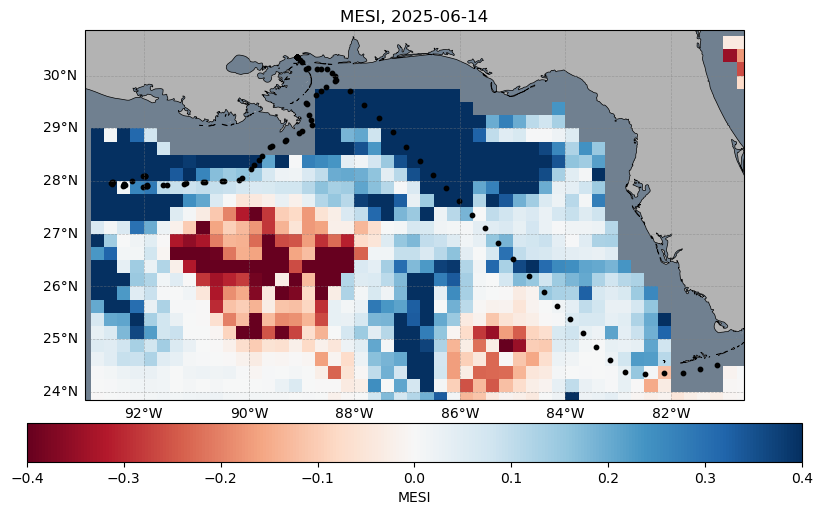

In [9]:
# Plot MESI

# Subset MESI data
map_data_subset = mesi_df[mesi_df["variable"] == "mesi"]

# Convert to grid for plotting
grid = map_data_subset.pivot(index="latitude", columns="longitude", values="value")

# Create map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot raster (MESI field)
mesh = ax.pcolormesh(
    grid.columns.values,
    grid.index.values,
    grid.values,
    cmap="RdBu",                 # diverging colormap (blue → red)
    vmin=-0.4,
    vmax=0.4,
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Add land and coastline
ax.add_feature(cfeature.LAND, facecolor="0.7")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Overlay ship track
ax.scatter(
    ship_2["longitude"],
    ship_2["latitude"],
    color="black",
    s=10,
    transform=ccrs.PlateCarree()
)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Title
ax.set_title(f"MESI, {midt}")

# Background color
ax.set_facecolor("slategray")

# Colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("MESI")

# Set map extent around ship track
ax.set_extent(
    [
        ship_2["longitude"].min() - plot_xpad,
        ship_2["longitude"].max() + plot_xpad,
        ship_2["latitude"].min() - plot_ypad,
        ship_2["latitude"].max() + plot_ypad,
    ],
    crs=ccrs.PlateCarree()
)

# Save and display
plt.savefig("MESImap.png", dpi=300, bbox_inches="tight")
plt.show()

## Make map of eddy location

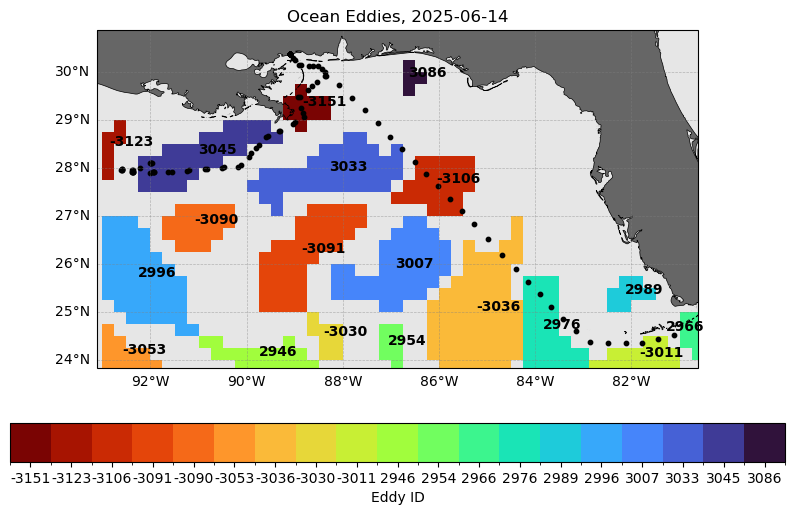

In [10]:
# Identify eddy centers (for labeling)
eddy_centers = (
    eddy_df[eddy_df["value"].abs() > 0]
    .groupby("value", as_index=False)
    .agg({"longitude": "mean", "latitude": "mean"})
)

# Subset nonzero eddy values
eddy_subset = eddy_df[eddy_df["value"].abs() > 0]

# Convert to grid for plotting
grid = eddy_subset.pivot(index="latitude", columns="longitude", values="value")

# Create indexed grid (categorical mapping of eddy IDs → integers)
unique_ids = np.sort(eddy_subset["value"].unique())
id_to_index = {eddy_id: i for i, eddy_id in enumerate(unique_ids)}

indexed_data = np.full(grid.shape, np.nan)
for eddy_id, idx in id_to_index.items():
    indexed_data[grid.values == eddy_id] = idx

# Discrete colormap (one color per eddy)
cmap = plt.get_cmap("turbo_r", len(unique_ids))
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, len(unique_ids) + 0.5, 1),
    ncolors=len(unique_ids)
)

# Create map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot eddy field
mesh = ax.pcolormesh(
    grid.columns.values,
    grid.index.values,
    indexed_data,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Add land and coastline
ax.add_feature(cfeature.LAND, facecolor="0.4")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Overlay ship track
ax.scatter(
    ship_2["longitude"],
    ship_2["latitude"],
    color="black",
    s=10,
    transform=ccrs.PlateCarree()
)

# Add eddy ID labels at centers
texts = []
for _, row in eddy_centers.iterrows():
    texts.append(
        ax.text(
            row["longitude"],
            row["latitude"],
            f"{int(row['value'])}",
            color="black",
            fontsize=10,
            weight="bold",
            transform=ccrs.PlateCarree()
        )
    )

adjust_text(texts, ax=ax)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Title
ax.set_title(f"Ocean Eddies, {midt}")

# Background color
ax.set_facecolor("0.9")

# Set map extent around ship track
ax.set_extent(
    [
        ship_2["longitude"].min() - plot_xpad,
        ship_2["longitude"].max() + plot_xpad,
        ship_2["latitude"].min() - plot_ypad,
        ship_2["latitude"].max() + plot_ypad,
    ],
    crs=ccrs.PlateCarree()
)

# Discrete colorbar with eddy IDs
cbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.12,
    ticks=np.arange(len(unique_ids))
)
cbar.set_label("Eddy ID")
cbar.ax.set_xticklabels([str(int(x)) for x in unique_ids])

# Save and display
plt.savefig("Eddymap.png", dpi=300, bbox_inches="tight")
plt.show()

The maps above show a snapshot of conditions in the middle of the cruise track. To see a more synoptic view of of conditions along the track we will extract the match-up data for the positions along the cruise track

## Get mesi values

In [11]:
# Make ship times timezone-naive UTC to match xarray indexing
ship_2["time"] = pd.to_datetime(ship_2["time"], utc=True).dt.tz_localize(None)

# Extract MESI values along the ship track
mesi_values = []

for _, row in ship_2.iterrows():
    # Get the nearest ship time as numpy datetime
    tval = pd.Timestamp(row["time"]).to_datetime64()

    # Define a small box around the ship location
    lat1 = row["latitude"] - 0.2
    lat2 = row["latitude"] + 0.2
    lon1 = row["longitude"] - 0.2
    lon2 = row["longitude"] + 0.2

    # Handle latitude order in the dataset
    if mesi_ds.latitude.values[0] > mesi_ds.latitude.values[-1]:
        lat_slice = slice(lat2, lat1)
    else:
        lat_slice = slice(lat1, lat2)

    # Subset the MESI field at the nearest time and average over the box
    subset = (
        mesi_ds["mesi"]
        .sel(time=tval, method="nearest")
        .sel(
            longitude=slice(lon1, lon2),
            latitude=lat_slice
        )
    )

    # Store the mean MESI value for this ship point
    mesi_values.append(subset.mean().item())

# Add extracted MESI values to the ship track table
ship_2["mesi"] = mesi_values

## Map tracks with mesi data

2025 Nancy Foster Tracks: Jun 10 - Jun 19, 2025


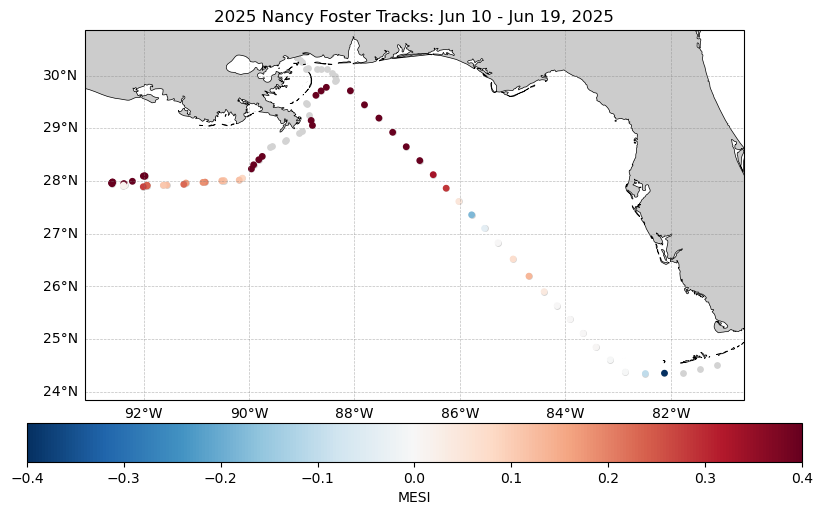

In [12]:
# Create plot title from ship time range
begtime = ship["time"].min().strftime("%b %d")
endtime = ship["time"].max().strftime("%b %d, %Y")
ptitle = f"2025 Nancy Foster Tracks: {begtime} - {endtime}"

print(ptitle)

# Plot ship track colored by MESI

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land and coastline
ax.add_feature(cfeature.LAND, facecolor="0.8")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Plot full track in gray (background)
ax.scatter(
    ship_2["longitude"],
    ship_2["latitude"],
    color="lightgray",
    s=15,
    transform=ccrs.PlateCarree(),
    zorder=1
)

# Plot only valid MESI values on top
valid = ship_2["mesi"].notna()

sc = ax.scatter(
    ship_2.loc[valid, "longitude"],
    ship_2.loc[valid, "latitude"],
    c=ship_2.loc[valid, "mesi"],
    cmap="RdBu_r",              # diverging colormap (blue → red)
    vmin=-0.4,
    vmax=0.4,
    s=15,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# Title
ax.set_title(ptitle)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Set map extent around ship track
ax.set_extent(
    [
        ship_2["longitude"].min() - plot_xpad,
        ship_2["longitude"].max() + plot_xpad,
        ship_2["latitude"].min() - plot_ypad,
        ship_2["latitude"].max() + plot_ypad,
    ],
    crs=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("MESI")

# Save and display
plt.savefig("mesi_track.png", dpi=300, bbox_inches="tight")
plt.show()

## Get eddy label (anti) values

In [13]:
# Initialize list to store extracted values
track2 = []

# Loop through each ship location
for _, row in ship_2.iterrows():
    # Convert time to numpy datetime for xarray selection
    tval = pd.Timestamp(row["time"]).to_datetime64()

    # Extract nearest anticyclonic eddy ID at this location and time
    subset = munster_ds["Label_anti"].sel(
        time=tval,
        longitude=row["longitude"],
        latitude=row["latitude"],
        method="nearest"
    )

    # Store the extracted value
    track2.append(subset.item())

# Add extracted values to the ship track dataframe
ship_2["Label_anti"] = track2

## Get eddy label (cyclo) values

In [14]:
# Initialize list to store extracted values
track3 = []

# Loop through each ship location
for _, row in ship_2.iterrows():
    # Convert time to numpy datetime for xarray selection
    tval = pd.Timestamp(row["time"]).to_datetime64()

    # Extract nearest cyclonic eddy ID at this location and time
    subset = munster_ds["Label_cyclo"].sel(
        time=tval,
        longitude=row["longitude"],
        latitude=row["latitude"],
        method="nearest"
    )

    # Store the extracted value
    track3.append(subset.item())

# Multiply by -1 so cyclonic eddies are negative (to distinguish from anticyclonic)
ship_2["Label_cyclo"] = -1 * np.array(track3)

# Combine cyclonic and anticyclonic labels into a single eddy ID field
ship_2["Label"] = ship_2["Label_cyclo"] + ship_2["Label_anti"]

## Map tracks with eddy locations

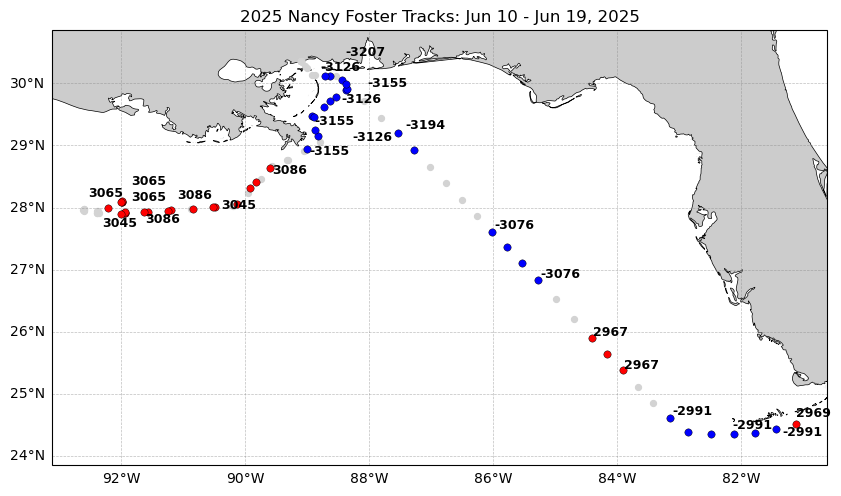

In [15]:
# Keep only ship points that fall inside an eddy
eddies = ship_2[ship_2["Label"].abs() > 0].copy()

# Keep ship points with valid coordinates for plotting
ship_plot = ship_2.dropna(subset=["longitude", "latitude"])

# Identify consecutive runs of the same eddy label
eddies["group"] = (eddies["Label"] != eddies["Label"].shift()).cumsum()

# Build a smaller set of points to label
eddies_label_list = []

for _, group_df in eddies.groupby("group"):
    group_df = group_df.reset_index(drop=True)
    n = len(group_df)

    # Label fewer points for short runs and more for long runs
    if n <= 2:
        keep_idx = [0]
    elif n <= 4:
        keep_idx = [0, n - 1]
    else:
        keep_idx = [0, n // 2, n - 1]

    eddies_label_list.append(group_df.loc[keep_idx])

# Combine label points and remove duplicates
eddies_label = pd.concat(eddies_label_list, ignore_index=True)
eddies_label = eddies_label.drop_duplicates(subset=["longitude", "latitude", "Label"])

# Split cyclonic and anticyclonic eddies for coloring
neg_eddies = eddies[eddies["Label"] < 0]
pos_eddies = eddies[eddies["Label"] > 0]

# Create map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land and coastline
ax.add_feature(cfeature.LAND, facecolor="0.8")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Plot all ship points in gray
ax.scatter(
    ship_plot["longitude"],
    ship_plot["latitude"],
    color="lightgray",
    s=18,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# Plot cyclonic eddies in blue
ax.scatter(
    neg_eddies["longitude"],
    neg_eddies["latitude"],
    color="blue",
    s=28,
    edgecolors="black",
    linewidths=0.3,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# Plot anticyclonic eddies in red
ax.scatter(
    pos_eddies["longitude"],
    pos_eddies["latitude"],
    color="red",
    s=28,
    edgecolors="black",
    linewidths=0.3,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# Add eddy labels
texts = []
for _, row in eddies_label.iterrows():
    texts.append(
        ax.text(
            row["longitude"],
            row["latitude"],
            f"{int(row['Label'])}",
            color="black",
            fontsize=9,
            weight="bold",
            transform=ccrs.PlateCarree(),
            zorder=4
        )
    )

adjust_text(texts, ax=ax)

# Title
ax.set_title(ptitle)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Set map extent around ship track
ax.set_extent(
    [
        ship_plot["longitude"].min() - plot_xpad,
        ship_plot["longitude"].max() + plot_xpad,
        ship_plot["latitude"].min() - plot_ypad,
        ship_plot["latitude"].max() + plot_ypad,
    ],
    crs=ccrs.PlateCarree()
)

# Save and display
plt.savefig("eddy_track.png", dpi=300, bbox_inches="tight")
plt.show()

## Extract EKE values along the ship track

In [16]:
# Initialize list to store extracted values
track4 = []

# Loop through each ship location
for _, row in ship_2.iterrows():
    # Convert time to numpy datetime for xarray selection
    tval = pd.Timestamp(row["time"]).to_datetime64()

    # Extract nearest EKE value at this location and time
    subset = mesi_ds["eke"].sel(
        time=tval,
        longitude=row["longitude"],
        latitude=row["latitude"],
        method="nearest"
    )

    # Store the extracted value
    track4.append(subset.item())

# Add extracted EKE values to the ship track dataframe
ship_2["eke"] = track4

## Map tracks with EKE data

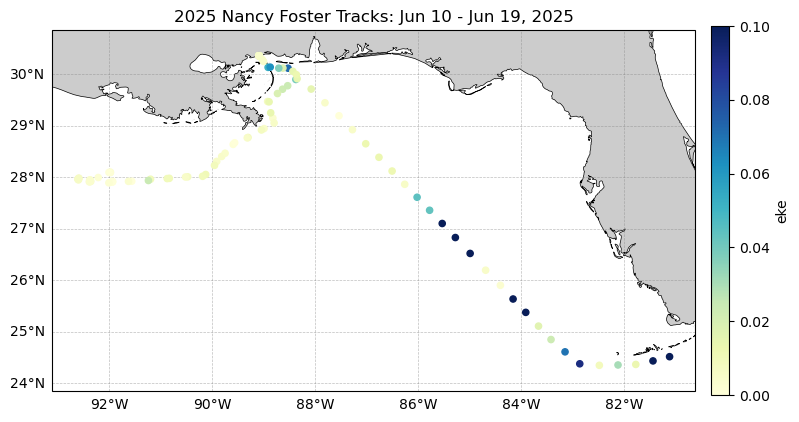

In [17]:
# Plot subset ship track colored by EKE

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land and coastline
ax.add_feature(cfeature.LAND, facecolor="0.8")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Plot ship track colored by EKE values
sc = ax.scatter(
    ship_2["longitude"],
    ship_2["latitude"],
    c=ship_2["eke"],          # color by EKE
    cmap=plt.cm.YlGnBu,       # blue → yellow colormap
    vmin=0,
    vmax=0.1,
    s=20,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# Title
ax.set_title(ptitle)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Set map extent around ship track
ax.set_extent(
    [
        ship_2["longitude"].min() - plot_xpad,
        ship_2["longitude"].max() + plot_xpad,
        ship_2["latitude"].min() - plot_ypad,
        ship_2["latitude"].max() + plot_ypad,
    ],
    crs=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02, shrink=0.8)
cbar.set_label("eke")

# Save and display
plt.savefig("eke_map.png", dpi=300, bbox_inches="tight")
plt.show()